In [1]:
!pwd


/home/stemjara/Projects/AWS-Architecture/whiteboard_selection_lab


In [4]:
import os
import networkx as nx
from collections import Counter, defaultdict
import pandas as pd
import json

# Definir la ruta relativa desde whiteboard_selection_lab/ hacia data/cloudscape_gt/
GT_DIR = os.path.abspath(os.path.join("..", "data", "cloudscape_gt"))

print(f"📂 Buscando archivos en: {GT_DIR}")
graphml_files = [f for f in os.listdir(GT_DIR) if f.endswith('.graphml')]
print(f"✅ Total de archivos GraphML encontrados: {len(graphml_files)}")

📂 Buscando archivos en: /home/stemjara/Projects/AWS-Architecture/data/cloudscape_gt
✅ Total de archivos GraphML encontrados: 164


In [5]:
service_counter = Counter()
errores = 0

for filename in graphml_files:
    filepath = os.path.join(GT_DIR, filename)
    try:
        # Leer el grafo usando networkx
        G = nx.read_graphml(filepath)
        for node_id, data in G.nodes(data=True):
            # Obtener el atributo 'service' (si no existe, lo marcamos como UNKNOWN)
            service = data.get('service', 'UNKNOWN')
            service_counter[service] += 1
    except Exception as e:
        errores += 1

print(f"⚠️ Archivos con errores de lectura: {errores}")

# Convertir a DataFrame para una visualización analítica
df_services = pd.DataFrame.from_dict(service_counter, orient='index', columns=['Frecuencia']).reset_index()
df_services.rename(columns={'index': 'Servicio'}, inplace=True)
df_services = df_services.sort_values(by='Frecuencia', ascending=False).reset_index(drop=True)

# Mostrar los top 40 servicios para identificar las categorías custom
display(df_services.head(40))

⚠️ Archivos con errores de lectura: 0


,Servicio,Frecuencia
0,S3,133
1,Lambda,130
2,EC2,91
3,ThirdParty,82
4,DynamoDB,56
5,UserConsumerWeb,45
6,EKS,44
7,SQS,43
8,UserConsumerMobile,37
9,ApiGateway,37


In [7]:
df_services.info()

<class 'pandas.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Servicio    136 non-null    str  
 1   Frecuencia  136 non-null    int64
dtypes: int64(1), str(1)
memory usage: 3.6 KB


In [6]:
# Lista de etiquetas sospechosas o que sabemos que no son servicios directos de AWS
# (Puedes agregar más a esta lista basándote en los resultados de la Celda 2)
custom_labels = [
    'UserConsumerWeb', 'UserConsumerMobile', 'UserCompanyAgent',
    'UserCompanyDeveloper', 'UserCompanyCRM', 'UserCompanyDataStream',
    'ThirdParty', 'OnPremDC'
]

mapping_data = defaultdict(list)

for filename in graphml_files:
    filepath = os.path.join(GT_DIR, filename)
    try:
        G = nx.read_graphml(filepath)
        for node_id, data in G.nodes(data=True):
            service = data.get('service', 'UNKNOWN')

            # Filtrar si es una etiqueta custom o si empieza con 'User'
            if service in custom_labels or service.startswith('User'):
                name = data.get('name', '').strip()
                notes = data.get('notes', '').strip()

                # Guardar solo si hay texto útil
                if name or notes:
                    mapping_data[service].append(f"Name: '{name}' | Notes: '{notes}'")
    except Exception:
        continue

# Imprimir muestras deduplicadas para construir las reglas
for service, examples in mapping_data.items():
    unique_examples = list(set(examples))
    print(f"\n🏷️ --- {service} ({len(unique_examples)} variaciones únicas) ---")

    # Mostrar hasta 10 ejemplos para entender el patrón del humano
    for ex in unique_examples[:10]:
        print(f"  - {ex}")


🏷️ --- ThirdParty (80 variaciones únicas) ---
  - Name: 'Legacy On-premise System' | Notes: 'NAME: Legacy On-premise System'
  - Name: 'Snowflake' | Notes: 'NAME: Snowflake'
  - Name: 'Multiple Data Sources' | Notes: 'NAME: Multiple Data Sources'
  - Name: 'Arango DB' | Notes: 'NAME: Arango DB'
  - Name: 'Scheduler where tasks are managed by customer' | Notes: 'NAME: Scheduler where tasks are managed by customer'
  - Name: 'Systems Manager (invokes a lot of lambdas)' | Notes: 'NAME: Systems Manager (invokes a lot of lambdas)'
  - Name: 'Neo4j, corelation engine' | Notes: 'NAME: Neo4j, corelation engine'
  - Name: 'SAP' | Notes: 'NAME: SAP'
  - Name: 'Okta' | Notes: 'NAME: Okta'
  - Name: 'unspecified AWS database services' | Notes: 'NOTES: database to cache videos metadata
NAME: unspecified AWS database services'


In [8]:
edge_patterns = Counter()

for filename in graphml_files:
    filepath = os.path.join(GT_DIR, filename)
    try:
        G = nx.read_graphml(filepath)
        for source, target, edge_data in G.edges(data=True):
            # Obtener el servicio de origen y destino
            src_service = G.nodes[source].get('service', 'UNKNOWN')
            tgt_service = G.nodes[target].get('service', 'UNKNOWN')

            # Registrar el patrón direccional
            edge_patterns[f"{src_service} -> {tgt_service}"] += 1
    except Exception:
        continue

# Convertir a DataFrame
df_edges = pd.DataFrame.from_dict(edge_patterns, orient='index', columns=['Frecuencia']).reset_index()
df_edges.rename(columns={'index': 'Flujo (Origen -> Destino)'}, inplace=True)
df_edges = df_edges.sort_values(by='Frecuencia', ascending=False).reset_index(drop=True)

# Mostrar los 30 flujos más comunes
display(df_edges.head(30))

,Flujo (Origen -> Destino),Frecuencia
0,ApiGateway -> Lambda,31
1,Lambda -> DynamoDB,30
2,DynamoDB -> Lambda,23
3,Lambda -> S3,23
4,EC2 -> S3,22
5,S3 -> Lambda,21
6,SQS -> Lambda,18
7,Lambda -> SQS,16
8,CloudFront -> S3,15
9,EC2 -> EC2,15


In [9]:
df_edges.info()

<class 'pandas.DataFrame'>
RangeIndex: 851 entries, 0 to 850
Data columns (total 2 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Flujo (Origen -> Destino)  851 non-null    str  
 1   Frecuencia                 851 non-null    int64
dtypes: int64(1), str(1)
memory usage: 30.3 KB


In [10]:
import os
import pandas as pd

# 1. Crear directorio de salida dentro de tu lab_workspace
OUTPUT_DIR = "analisis_ground_truth"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 2. Exportar los DataFrames principales
ruta_servicios = os.path.join(OUTPUT_DIR, "1_frecuencia_servicios.csv")
df_services.to_csv(ruta_servicios, index=False, encoding='utf-8')

ruta_flujos = os.path.join(OUTPUT_DIR, "2_frecuencia_flujos_edges.csv")
df_edges.to_csv(ruta_flujos, index=False, encoding='utf-8')

# 3. Exportar el mapeo de textos (Convertir el diccionario a un DataFrame limpio)
filas_mapeo = []
for servicio, ejemplos in mapping_data.items():
    # Usamos set() para quitar duplicados
    for ejemplo in set(ejemplos):
        filas_mapeo.append({'Etiqueta_Asignada': servicio, 'Texto_Original_del_Humano': ejemplo})

df_mapeo = pd.DataFrame(filas_mapeo)
ruta_mapeo = os.path.join(OUTPUT_DIR, "3_mapeo_textos_humanos.csv")
df_mapeo.to_csv(ruta_mapeo, index=False, encoding='utf-8')

print(f"✅ Exportación completada. Archivos guardados en la carpeta: '{OUTPUT_DIR}'")
print(f"   - {ruta_servicios}")
print(f"   - {ruta_flujos}")
print(f"   - {ruta_mapeo}")

✅ Exportación completada. Archivos guardados en la carpeta: 'analisis_ground_truth'
   - analisis_ground_truth/1_frecuencia_servicios.csv
   - analisis_ground_truth/2_frecuencia_flujos_edges.csv
   - analisis_ground_truth/3_mapeo_textos_humanos.csv


/tmp/ipykernel_183737/3273091531.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


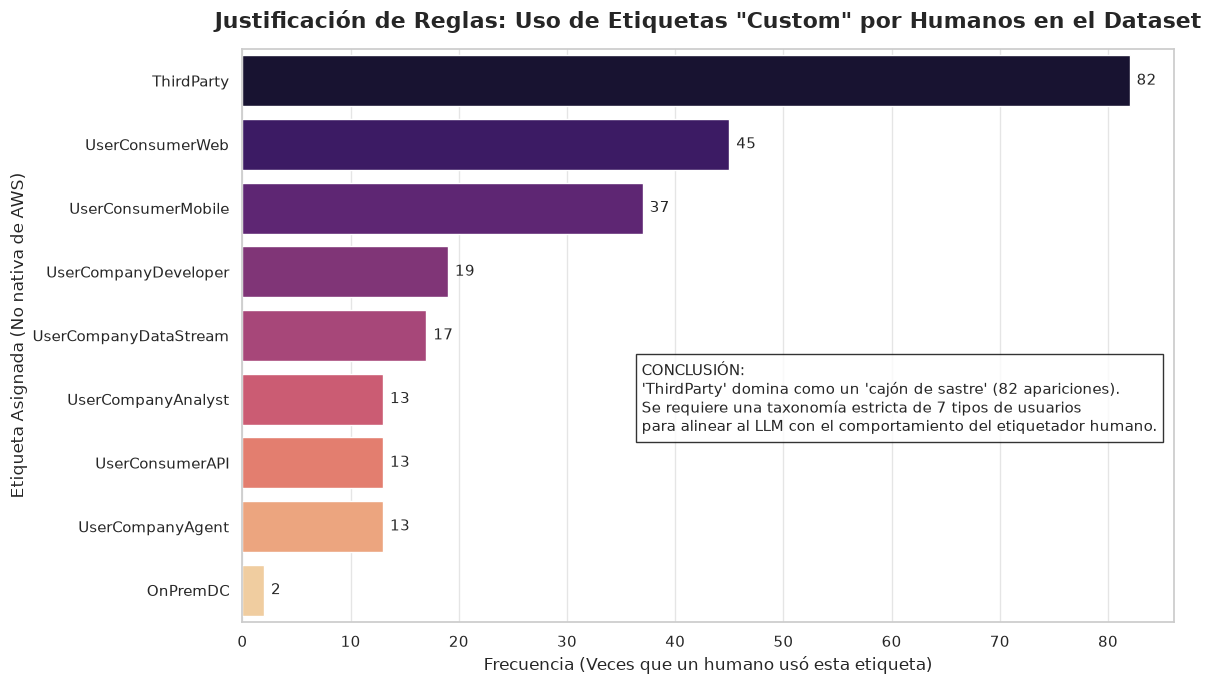

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo del gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Definir las etiquetas custom que descubrimos que los humanos inventaron/usaron
etiquetas_custom = [
    'ThirdParty', 'UserConsumerWeb', 'UserConsumerMobile',
    'UserCompanyDeveloper', 'UserCompanyDataStream',
    'UserCompanyAnalyst', 'UserCompanyAgent', 'UserConsumerAPI', 'OnPremDC'
]

# Filtrar el DataFrame original para quedarnos solo con estas etiquetas
df_justificacion = df_services[df_services['Servicio'].isin(etiquetas_custom)].copy()
df_justificacion = df_justificacion.sort_values(by='Frecuencia', ascending=False)

# Crear el gráfico de barras horizontales
ax = sns.barplot(
    data=df_justificacion,
    x='Frecuencia',
    y='Servicio',
    palette='magma' # Paleta de colores para resaltar impacto
)

# Añadir títulos y etiquetas
plt.title('Justificación de Reglas: Uso de Etiquetas "Custom" por Humanos en el Dataset', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Frecuencia (Veces que un humano usó esta etiqueta)', fontsize=12)
plt.ylabel('Etiqueta Asignada (No nativa de AWS)', fontsize=12)

# Añadir el número exacto al final de cada barra para mayor claridad
for i in ax.containers:
    ax.bar_label(i, padding=5, fontsize=11)

# Añadir una caja de texto explicativa en el gráfico (opcional, excelente para reportes)
texto_explicativo = (
    "CONCLUSIÓN:\n"
    "'ThirdParty' domina como un 'cajón de sastre' (82 apariciones).\n"
    "Se requiere una taxonomía estricta de 7 tipos de usuarios\n"
    "para alinear al LLM con el comportamiento del etiquetador humano."
)
plt.text(
    x=df_justificacion['Frecuencia'].max() * 0.45,
    y=5.5,
    s=texto_explicativo,
    fontsize=11,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='black')
)

plt.tight_layout()
plt.show()

In [12]:
rute_compare = '/home/stemjara/Projects/AWS-Architecture/whiteboard_selection_lab/three_graphs_comparison.csv'

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el CSV
df = pd.read_csv(rute_compare)

# 2. Filtrar únicamente los videos válidos
df_valid = df[df["is_valid_evaluation"] == True].copy()

# Forzar tipos numéricos
float_cols = [
    "std_svc_precision", "std_svc_recall", "std_svc_f1",
    "std_edge_precision", "std_edge_recall", "std_edge_f1",
    "pars_svc_precision", "pars_svc_recall", "pars_svc_f1",
    "pars_edge_precision", "pars_edge_recall", "pars_edge_f1"
]
for col in float_cols:
    df_valid[col] = pd.to_numeric(df_valid[col])

print(f"Cargados {len(df_valid)} videos válidos para evaluación.")

# 3. Mostrar resumen de promedios
resumen = pd.DataFrame({
    "Métrica": ["Service Precision", "Service Recall", "Service F1", "Edge Precision", "Edge Recall", "Edge F1"],
    "Standard": [
        df_valid["std_svc_precision"].mean(),
        df_valid["std_svc_recall"].mean(),
        df_valid["std_svc_f1"].mean(),
        df_valid["std_edge_precision"].mean(),
        df_valid["std_edge_recall"].mean(),
        df_valid["std_edge_f1"].mean()
    ],
    "Parsimonious": [
        df_valid["pars_svc_precision"].mean(),
        df_valid["pars_svc_recall"].mean(),
        df_valid["pars_svc_f1"].mean(),
        df_valid["pars_edge_precision"].mean(),
        df_valid["pars_edge_recall"].mean(),
        df_valid["pars_edge_f1"].mean()
    ]
})
resumen


Cargados 27 videos válidos para evaluación.


,Métrica,Standard,Parsimonious
0,Service Precision,0.801474,0.833959
1,Service Recall,0.815404,0.814385
2,Service F1,0.805956,0.820622
3,Edge Precision,0.487593,0.631963
4,Edge Recall,0.505656,0.522815
5,Edge F1,0.487600,0.563359


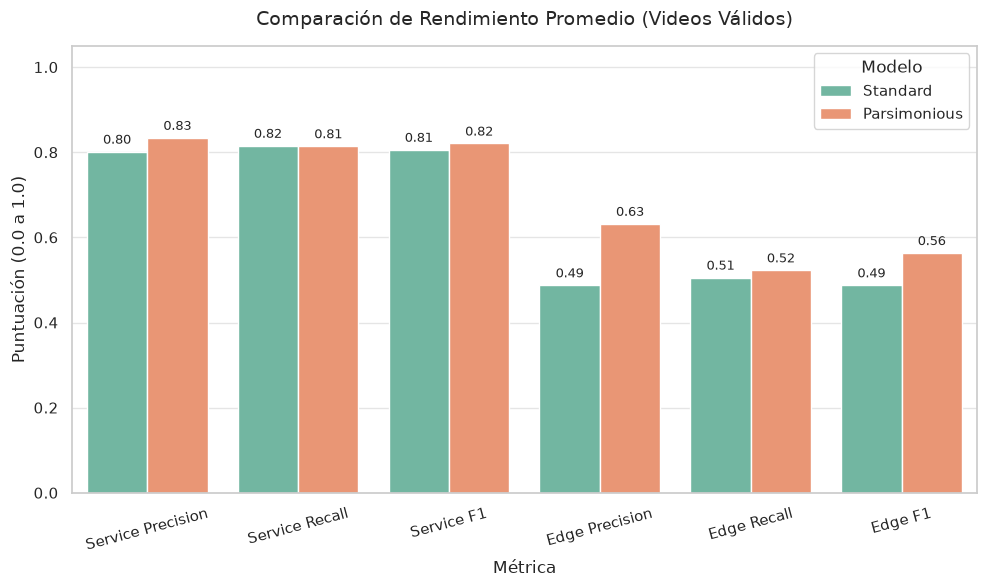

In [14]:
# Configurar estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# Reformatear para el gráfico
melted_resumen = pd.melt(resumen, id_vars="Métrica", var_name="Modelo", value_name="Score")

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=melted_resumen, x="Métrica", y="Score", hue="Modelo", palette="Set2")
plt.title("Comparación de Rendimiento Promedio (Videos Válidos)", fontsize=14, pad=15)
plt.ylabel("Puntuación (0.0 a 1.0)")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)

# Añadir valores sobre las barras
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height:.2f}",
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 8),
                    textcoords='offset points',
                    fontsize=9)

plt.tight_layout()
plt.show()


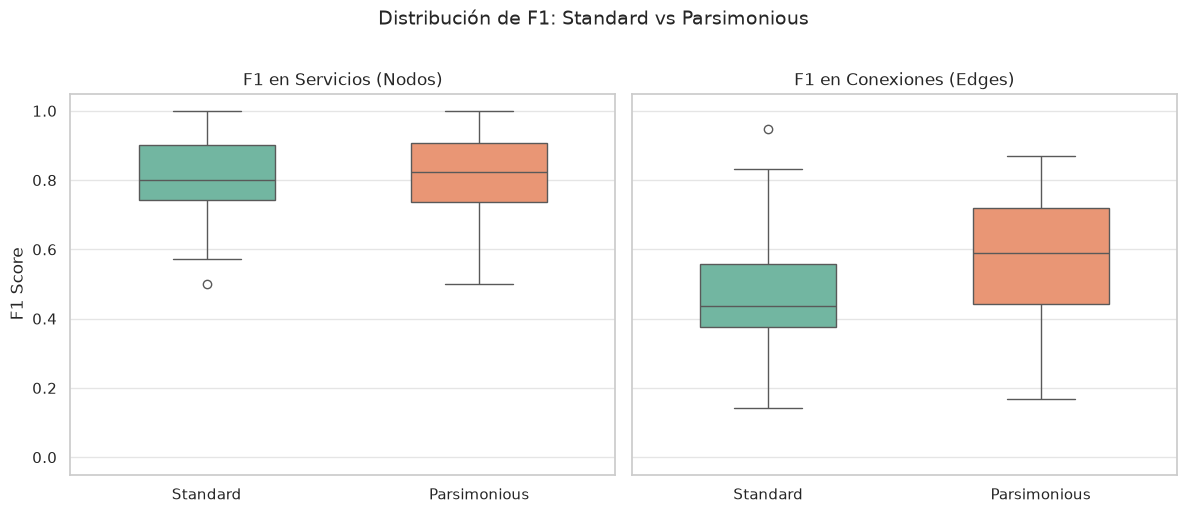

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Formatear datos de servicios
services_df = pd.melt(df_valid, value_vars=["std_svc_f1", "pars_svc_f1"],
                      var_name="Modelo", value_name="F1 Score")
services_df["Modelo"] = services_df["Modelo"].map({"std_svc_f1": "Standard", "pars_svc_f1": "Parsimonious"})

# Formatear datos de conexiones
edges_df = pd.melt(df_valid, value_vars=["std_edge_f1", "pars_edge_f1"],
                   var_name="Modelo", value_name="F1 Score")
edges_df["Modelo"] = edges_df["Modelo"].map({"std_edge_f1": "Standard", "pars_edge_f1": "Parsimonious"})

# Graficar
sns.boxplot(data=services_df, x="Modelo", y="F1 Score", ax=axes[0], hue="Modelo", palette="Set2", legend=False, width=0.5)
axes[0].set_title("F1 en Servicios (Nodos)")
axes[0].set_ylabel("F1 Score")
axes[0].set_ylim(-0.05, 1.05)
axes[0].set_xlabel("")

sns.boxplot(data=edges_df, x="Modelo", y="F1 Score", ax=axes[1], hue="Modelo", palette="Set2", legend=False, width=0.5)
axes[1].set_title("F1 en Conexiones (Edges)")
axes[1].set_ylabel("")
axes[1].set_xlabel("")

plt.suptitle("Distribución de F1: Standard vs Parsimonious", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


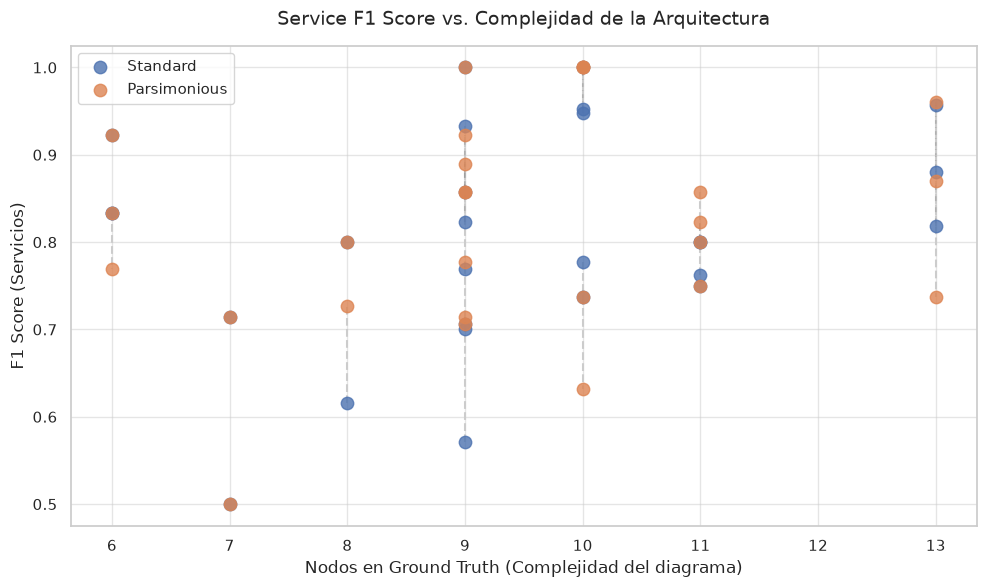

In [16]:
plt.figure(figsize=(10, 6))

# Graficar puntos
plt.scatter(df_valid["gt_nodes"], df_valid["std_svc_f1"], label="Standard", alpha=0.8, s=80, color="#4c72b0")
plt.scatter(df_valid["gt_nodes"], df_valid["pars_svc_f1"], label="Parsimonious", alpha=0.8, s=80, color="#dd8452")

# Dibujar líneas conectoras por cada video
for _, row in df_valid.iterrows():
    plt.plot([row["gt_nodes"], row["gt_nodes"]], [row["std_svc_f1"], row["pars_svc_f1"]],
             color="grey", linestyle="--", alpha=0.4, zorder=0)

plt.title("Service F1 Score vs. Complejidad de la Arquitectura", fontsize=14, pad=15)
plt.xlabel("Nodos en Ground Truth (Complejidad del diagrama)")
plt.ylabel("F1 Score (Servicios)")
plt.legend()
plt.tight_layout()
plt.show()
